In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:

# Load CSV file
df = pd.read_csv('spam.csv', encoding='latin-1')
df.columns = ['label', 'message', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

In [45]:
print(df.head())
print(df.tail())
print(df.isnull().sum())


  label                                            message Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
     label                                            message Unnamed: 2  \
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham               

In [46]:
print(df.shape)
print(df.columns)

(5572, 5)
Index(['label', 'message', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [47]:
df = df.iloc[:, :2]
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [48]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [49]:
print(df['label'].value_counts())  # How many spam vs ham
print(df['message'].nunique())     # How many unique messages
print(df.duplicated().sum())       # How many duplicate rows

label
ham     4825
spam     747
Name: count, dtype: int64
5169
403


In [50]:
df.dtypes

label      object
message    object
dtype: object

In [51]:
df = df.drop_duplicates()
print(f"after dropping duplicates: {df.shape}")

after dropping duplicates: (5169, 2)


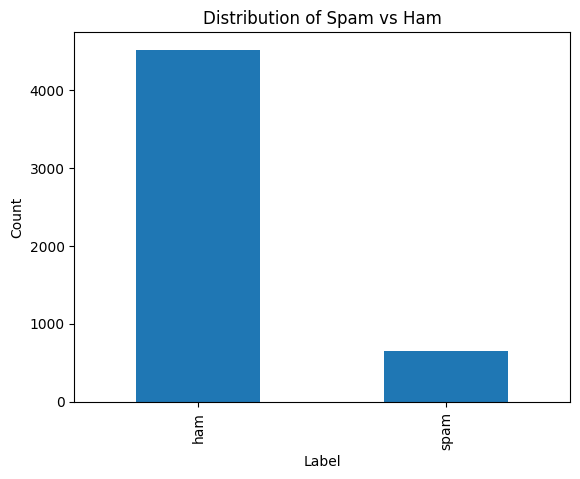

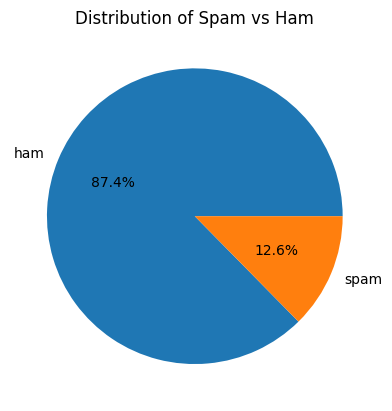

In [52]:
# DATA VISUALIZATION 
df['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Spam vs Ham')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Spam vs Ham')

plt.ylabel('')
plt.show()

In [53]:
# RATIO OF HAM TO SPAM : this means for each spam message, how many ham messages are there
spam_count = df[df['label'] == 'spam'].shape[0]
ham_count = df[df['label'] == 'ham'].shape[0]
ratio = ham_count / spam_count
print(f"Ham to Spam ratio: {ratio:.2f}:1")

Ham to Spam ratio: 6.92:1


In [54]:
# Analyze message length (in characters)
df['message_length'] = df['message'].str.len()

# Statistical summary by label (ham vs spam)
length_stats_by_label = df.groupby('label')['message_length'].describe()

print("Message length summary by label:")
print(length_stats_by_label)

# Optional: compare central tendency and spread directly
print("\nKey stats (mean, median, std) by label:")
print(
    df.groupby('label')['message_length']
      .agg(['mean', 'median', 'std', 'min', 'max'])
)

Message length summary by label:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
spam    653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0

Key stats (mean, median, std) by label:
             mean  median        std  min  max
label                                         
ham     70.459256    52.0  56.358207    2  910
spam   137.891271   149.0  30.137753   13  224


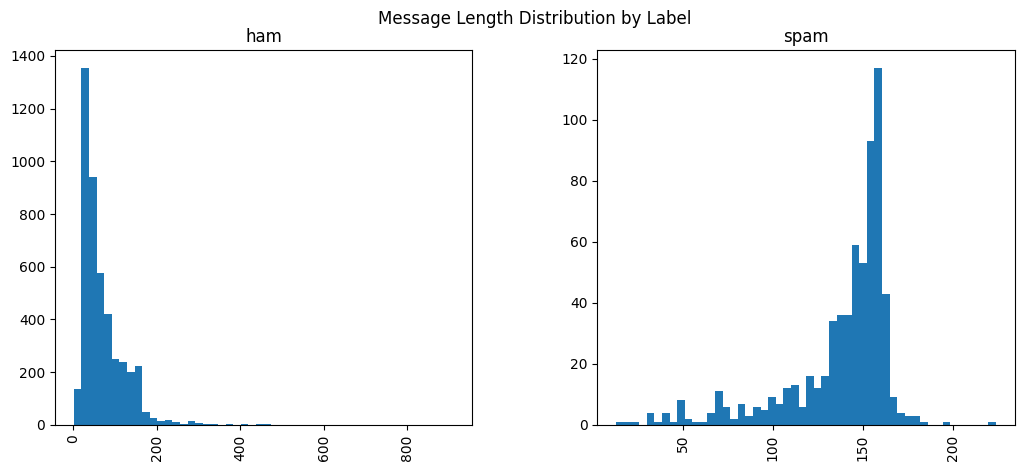

In [55]:
# Visualize message length distribution by label
df.hist(column='message_length', by='label', bins=50, figsize=(12, 5))
plt.suptitle('Message Length Distribution by Label')
plt.show()

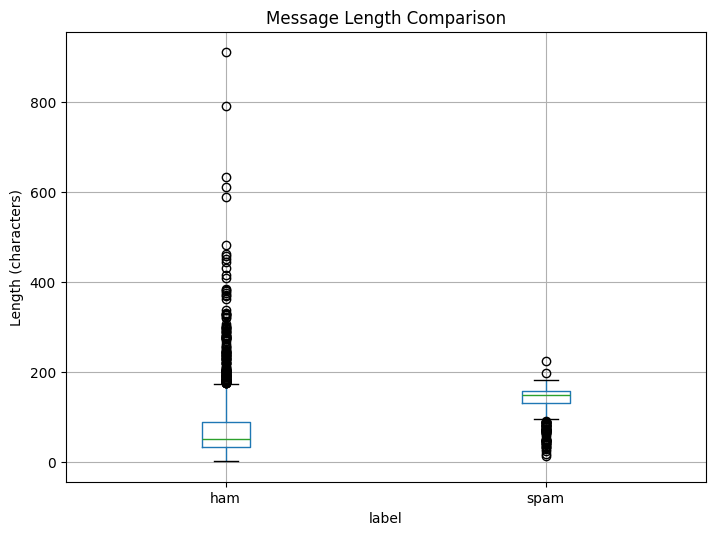

In [56]:
df.boxplot(column='message_length', by='label', figsize=(8, 6))
plt.title('Message Length Comparison')
plt.suptitle('')  # Remove default title
plt.ylabel('Length (characters)')
plt.show()

we can see that the median of the ham is less than the spam then  we can conclude that spam is typically longer
also we can see that the box of the ham is bigger so we can conclude that the ham varies more than teh spam in the middle 50%
we can see that also both has outliers so some unusual messages exists 
but for the two whiskers we can see that the ham varies more in total 

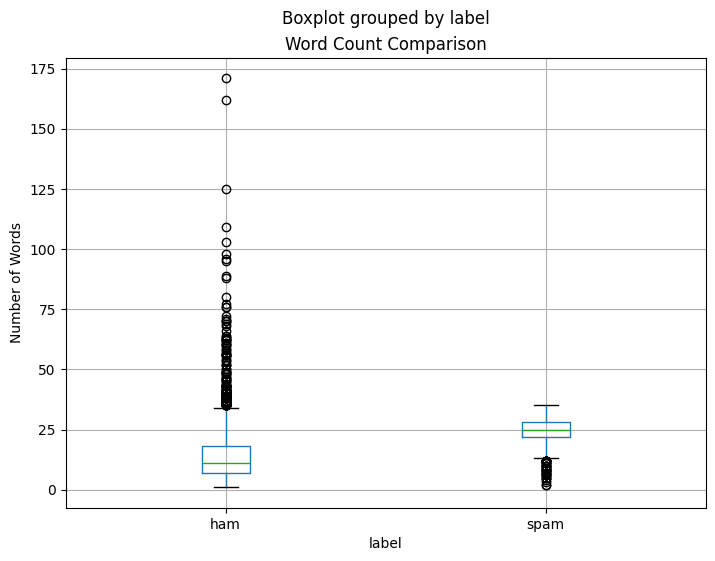

In [57]:
df['word_count'] = df['message'].str.split().str.len()

df.boxplot(column='word_count', by='label', figsize=(8, 6))
plt.title('Word Count Comparison')
plt.ylabel('Number of Words')
plt.show()

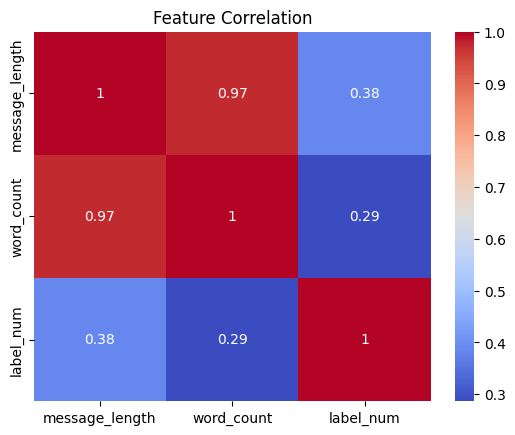

In [58]:


# Encode label as numeric
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

corr = df[['message_length', 'word_count', 'label_num']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [59]:
# Compare all three
Q1 = df['message_length'].quantile(0.25)
Q3 = df['message_length'].quantile(0.75)
IQR = Q3 - Q1

method1 = df[df['message_length'] > Q3 + 1.5*IQR]
method2 = df[np.abs(df['message_length'] - df['message_length'].mean()) > 3*df['message_length'].std()]
method3 = df[df['message_length'] > df['message_length'].quantile(0.95)]

print(f"IQR method: {len(method1)} outliers")
print(f"Z-score method: {len(method2)} outliers")
print(f"95th percentile: {len(method3)} outliers")

IQR method: 66 outliers
Z-score method: 56 outliers
95th percentile: 259 outliers


In [60]:
# Get the actual threshold values
Q1 = df['message_length'].quantile(0.25)
Q3 = df['message_length'].quantile(0.75)
IQR = Q3 - Q1
iqr_threshold = Q3 + 1.5*IQR

zscore_threshold = df['message_length'].mean() + 3*df['message_length'].std()
percentile_threshold = df['message_length'].quantile(0.95)

print(f"IQR threshold: {iqr_threshold:.0f}")
print(f"Z-score threshold: {zscore_threshold:.0f}")
print(f"95th percentile threshold: {percentile_threshold:.0f}")

# Check overlap
iqr_outliers = set(method1.index)
zscore_outliers = set(method2.index)
percentile_outliers = set(method3.index)

print(f"\nIQR outliers in 95th percentile: {len(iqr_outliers & percentile_outliers)}/{len(iqr_outliers)}")
print(f"Z-score outliers in 95th percentile: {len(zscore_outliers & percentile_outliers)}/{len(zscore_outliers)}")

IQR threshold: 238
Z-score threshold: 254
95th percentile threshold: 161

IQR outliers in 95th percentile: 66/66
Z-score outliers in 95th percentile: 56/56


In [61]:
# Display some examples of spam messages
print("=== SPAM EXAMPLES ===")
print(df[df['label'] == 'spam']['message'].sample(10).values)


# Longest spam messages
print("\n=== LONGEST SPAM ===")
print(df[df['label'] == 'spam'].nlargest(5, 'message_length')[['message', 'message_length']])

=== SPAM EXAMPLES ===
['PRIVATE! Your 2003 Account Statement for shows 800 un-redeemed S. I. M. points. Call 08715203652 Identifier Code: 42810 Expires 29/10/0'
 'This is the 2nd time we have tried to contact u. U have won the å£400 prize. 2 claim is easy, just call 087104711148 NOW! Only 10p per minute. BT-national-rate'
 'As one of our registered subscribers u can enter the draw 4 a 100 G.B. gift voucher by replying with ENTER. To unsubscribe text STOP'
 '-PLS STOP bootydelious (32/F) is inviting you to be her friend. Reply YES-434 or NO-434 See her: www.SMS.ac/u/bootydelious STOP? Send STOP FRND to 62468'
 'FREE>Ringtone! Reply REAL or POLY eg REAL1 1. PushButton 2. DontCha 3. BabyGoodbye 4. GoldDigger 5. WeBeBurnin 1st tone FREE and 6 more when u join for å£3/wk'
 '85233 FREE>Ringtone!Reply REAL'
 'Send a logo 2 ur lover - 2 names joined by a heart. Txt LOVE NAME1 NAME2 MOBNO eg LOVE ADAM EVE 07123456789 to 87077 Yahoo! POBox36504W45WQ TxtNO 4 no ads 150p'
 '07732584351 - Rodger Bu

In [62]:
# Display some examples of ham messages
print("\n=== HAM EXAMPLES ===")
print(df[df['label'] == 'ham']['message'].sample(10).values)
#shortest ham messages
print("\n=== SHORTEST HAM ===")
print(df[df['label'] == 'ham'].nsmallest(5, 'message_length')[['message', 'message_length']])


=== HAM EXAMPLES ===
['I thk 50 shd be ok he said plus minus 10.. Did Ì_ leave a line in between paragraphs?'
 'Good afternoon, my boytoy ... How are you feeling today ? Better I hope? Are you being my good boy? Are you my obedient, slave? Do you please your Queen?'
 "Call me when u're done..." 'What pa tell me.. I went to bath:-)'
 'meet you in corporation st outside gap \x89Û_ you can see how my mind is working!'
 'Thanks for picking up the trash.'
 'Many more happy returns of the day. I wish you happy birthday.'
 'Heart is empty without love.. Mind is empty without wisdom.. Eyes r empty without dreams &amp; Life is empty without frnds.. So Alwys Be In Touch. Good night &amp; sweet dreams'
 'Its ok chikku, and its my 1 of favourite song..:-)'
 'Er mw im filled tuth is aight']

=== SHORTEST HAM ===
     message  message_length
1924      Ok               2
260      Yup               3
1611     645               3
2181     Ok.               3
3374     :)                3


# 1-Preprocessing 

In [63]:
import textacy
import textacy.preprocessing as tprep


### LowerCasing the messages 

In [64]:
df['message'] = df['message'].str.lower()

### Normalization (whitespace, accents, hyphenated_words)

In [65]:
# i counted the lower case under the normalization 
def normalize_text(text):
    text = tprep.normalize.whitespace(text)
    text = tprep.remove.accents(text)
    text = tprep.normalize.hyphenated_words(text)
    return text

df['messages'] = df['message'].apply(normalize_text)

### Cleaning Noise

In [66]:
# Check what's available in textacy
print("Available textacy.preprocessing functions:")
print([x for x in dir(tprep) if not x.startswith('_')])

Available textacy.preprocessing functions:
['make_pipeline', 'normalize', 'pipeline', 'remove', 'replace', 'resources']


In [67]:
# clean noise (html, tags, punctuation , etc......)

def clean_text(text):
    text = tprep.normalize.whitespace(text)
    text = tprep.remove.html_tags(text)
    # Replace URLs with token (keep the signal!)
    text = tprep.replace.urls(text, '[URL]')
    text = tprep.replace.emails(text, '[EMAIL]')
    text = tprep.replace.phone_numbers(text, '[PHONE]')
    return text
df['clean_message'] = df['message'].apply(clean_text)
print(df[['message', 'clean_message']].head(10))

                                             message  \
0  go until jurong point, crazy.. available only ...   
1                      ok lar... joking wif u oni...   
2  free entry in 2 a wkly comp to win fa cup fina...   
3  u dun say so early hor... u c already then say...   
4  nah i don't think he goes to usf, he lives aro...   
5  freemsg hey there darling it's been 3 week's n...   
6  even my brother is not like to speak with me. ...   
7  as per your request 'melle melle (oru minnamin...   
8  winner!! as a valued network customer you have...   
9  had your mobile 11 months or more? u r entitle...   

                                       clean_message  
0  go until jurong point, crazy.. available only ...  
1                      ok lar... joking wif u oni...  
2  free entry in 2 a wkly comp to win fa cup fina...  
3  u dun say so early hor... u c already then say...  
4  nah i don't think he goes to usf, he lives aro...  
5  freemsg hey there darling it's been 3 week's n... 

### Contractions


In [68]:
# !pip install contractions
import contractions

In [69]:
def expand_contractions(text):
    return contractions.fix(text)
df['expanded_message'] = df['clean_message'].apply(expand_contractions)
print(df[['clean_message', 'expanded_message']].head(10))

                                       clean_message  \
0  go until jurong point, crazy.. available only ...   
1                      ok lar... joking wif u oni...   
2  free entry in 2 a wkly comp to win fa cup fina...   
3  u dun say so early hor... u c already then say...   
4  nah i don't think he goes to usf, he lives aro...   
5  freemsg hey there darling it's been 3 week's n...   
6  even my brother is not like to speak with me. ...   
7  as per your request 'melle melle (oru minnamin...   
8  winner!! as a valued network customer you have...   
9  had your mobile 11 months or more? u r entitle...   

                                    expanded_message  
0  go until jurong point, crazy.. available only ...  
1                    ok lar... joking wif you oni...  
2  free entry in 2 a wkly comp to win fa cup fina...  
3  you dun say so early hor... you c already then...  
4  nah i do not think he goes to usf, he lives ar...  
5  freemsg hey there darling it is been 3 week's ... 

### Tokenization and Stop Word Removal


In [70]:
# !pip install nltk 
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [71]:
# using NLTK for tokenization 
df['tokens'] = df['expanded_message'].apply(word_tokenize)
print(df[['expanded_message', 'tokens']].head(10))

                                    expanded_message  \
0  go until jurong point, crazy.. available only ...   
1                    ok lar... joking wif you oni...   
2  free entry in 2 a wkly comp to win fa cup fina...   
3  you dun say so early hor... you c already then...   
4  nah i do not think he goes to usf, he lives ar...   
5  freemsg hey there darling it is been 3 week's ...   
6  even my brother is not like to speak with me. ...   
7  as per your request 'melle melle (oru minnamin...   
8  winner!! as a valued network customer you have...   
9  had your mobile 11 months or more? you r entit...   

                                              tokens  
0  [go, until, jurong, point, ,, crazy, .., avail...  
1         [ok, lar, ..., joking, wif, you, oni, ...]  
2  [free, entry, in, 2, a, wkly, comp, to, win, f...  
3  [you, dun, say, so, early, hor, ..., you, c, a...  
4  [nah, i, do, not, think, he, goes, to, usf, ,,...  
5  [freemsg, hey, there, darling, it, is, been, 3... 

In [72]:
# Get English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from tokens
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens_clean'] = df['tokens'].apply(remove_stopwords)

# Compare before and after
print(df[['tokens', 'tokens_clean']].head(10))

                                              tokens  \
0  [go, until, jurong, point, ,, crazy, .., avail...   
1         [ok, lar, ..., joking, wif, you, oni, ...]   
2  [free, entry, in, 2, a, wkly, comp, to, win, f...   
3  [you, dun, say, so, early, hor, ..., you, c, a...   
4  [nah, i, do, not, think, he, goes, to, usf, ,,...   
5  [freemsg, hey, there, darling, it, is, been, 3...   
6  [even, my, brother, is, not, like, to, speak, ...   
7  [as, per, your, request, 'melle, melle, (, oru...   
8  [winner, !, !, as, a, valued, network, custome...   
9  [had, your, mobile, 11, months, or, more, ?, y...   

                                        tokens_clean  
0  [go, jurong, point, ,, crazy, .., available, b...  
1              [ok, lar, ..., joking, wif, oni, ...]  
2  [free, entry, 2, wkly, comp, win, fa, cup, fin...  
3  [dun, say, early, hor, ..., c, already, say, ...]  
4  [nah, think, goes, usf, ,, lives, around, though]  
5  [freemsg, hey, darling, 3, week, 's, word, bac... 

### POS (Part-of-Speech Tagging)

In [73]:
# Download required NLTK data
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [74]:
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer
wnl = WordNetLemmatizer()

# Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(treebank_tag):
    """
    Convert NLTK POS tag to WordNet POS tag
    NLTK uses tags like 'NN', 'VB', 'JJ', 'RB'
    WordNet uses 'n' (noun), 'v' (verb), 'a' (adjective), 'r' (adverb)
    """
    if treebank_tag.startswith('J'):
        return wordnet.ADJ      # Adjective
    elif treebank_tag.startswith('V'):
        return wordnet.VERB     # Verb
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN     # Noun
    elif treebank_tag.startswith('R'):
        return wordnet.ADV      # Adverb
    else:
        return wordnet.NOUN     # Default to noun

# Lemmatize with POS tags for better accuracy
def lemmatize_with_pos(tokens):
    # Get POS tags for each token
    pos_tags = pos_tag(tokens)
    
    # Lemmatize each word with its POS tag
    lemmatized = []
    for word, tag in pos_tags:
        wordnet_pos = get_wordnet_pos(tag)
        lemmatized.append(wnl.lemmatize(word, pos=wordnet_pos))
    
    return lemmatized

# Apply to your tokens
df['tokens_lemmatized_pos'] = df['tokens_clean'].apply(lemmatize_with_pos)

# Compare results
print(df[['tokens_clean', 'tokens_lemmatized_pos']].head(10))

                                        tokens_clean  \
0  [go, jurong, point, ,, crazy, .., available, b...   
1              [ok, lar, ..., joking, wif, oni, ...]   
2  [free, entry, 2, wkly, comp, win, fa, cup, fin...   
3  [dun, say, early, hor, ..., c, already, say, ...]   
4  [nah, think, goes, usf, ,, lives, around, though]   
5  [freemsg, hey, darling, 3, week, 's, word, bac...   
6  [even, brother, like, speak, ., treat, like, a...   
7  [per, request, 'melle, melle, (, oru, minnamin...   
8  [winner, !, !, valued, network, customer, sele...   
9  [mobile, 11, months, ?, r, entitled, update, l...   

                               tokens_lemmatized_pos  
0  [go, jurong, point, ,, crazy, .., available, b...  
1                [ok, lar, ..., joke, wif, oni, ...]  
2  [free, entry, 2, wkly, comp, win, fa, cup, fin...  
3  [dun, say, early, hor, ..., c, already, say, ...]  
4     [nah, think, go, usf, ,, live, around, though]  
5  [freemsg, hey, darling, 3, week, 's, word, bac... 

In [75]:
print(df[['tokens', 'tokens_clean', 'tokens_lemmatized_pos']].head(10))

                                              tokens  \
0  [go, until, jurong, point, ,, crazy, .., avail...   
1         [ok, lar, ..., joking, wif, you, oni, ...]   
2  [free, entry, in, 2, a, wkly, comp, to, win, f...   
3  [you, dun, say, so, early, hor, ..., you, c, a...   
4  [nah, i, do, not, think, he, goes, to, usf, ,,...   
5  [freemsg, hey, there, darling, it, is, been, 3...   
6  [even, my, brother, is, not, like, to, speak, ...   
7  [as, per, your, request, 'melle, melle, (, oru...   
8  [winner, !, !, as, a, valued, network, custome...   
9  [had, your, mobile, 11, months, or, more, ?, y...   

                                        tokens_clean  \
0  [go, jurong, point, ,, crazy, .., available, b...   
1              [ok, lar, ..., joking, wif, oni, ...]   
2  [free, entry, 2, wkly, comp, win, fa, cup, fin...   
3  [dun, say, early, hor, ..., c, already, say, ...]   
4  [nah, think, goes, usf, ,, lives, around, though]   
5  [freemsg, hey, darling, 3, week, 's, word, b

### Alternative: Stemming (Commented Out)

In [76]:
# STEMMING - More aggressive, faster but less accurate
# Uncomment if you want to try stemming instead of lemmatization

# from nltk.stem import PorterStemmer
# ps = PorterStemmer()
# def stem_tokens(tokens):
#     return [ps.stem(word) for word in tokens]

# df['tokens_stemmed'] = df['tokens_clean'].apply(stem_tokens)# print(df[['tokens_clean', 'tokens_stemmed']].head(10))

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data


In [78]:
# Join tokens into string
df['final_text'] = df['tokens_lemmatized_pos'].apply(lambda x: ' '.join(x))
print(df[['final_text', 'tokens_lemmatized_pos']].head(10))
X = df['final_text']      # Features (as text string)
y = df['label_num']       # Target (0 = ham, 1 = spam)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


                                          final_text  \
0  go jurong point , crazy .. available bugis n g...   
1                        ok lar ... joke wif oni ...   
2  free entry 2 wkly comp win fa cup final tkts 2...   
3            dun say early hor ... c already say ...   
4              nah think go usf , live around though   
5  freemsg hey darling 3 week 's word back ! woul...   
6  even brother like speak . treat like aid patent .   
7  per request 'melle melle ( oru minnaminunginte...   
8  winner ! ! value network customer select recei...   
9  mobile 11 month ? r entitle update late colour...   

                               tokens_lemmatized_pos  
0  [go, jurong, point, ,, crazy, .., available, b...  
1                [ok, lar, ..., joke, wif, oni, ...]  
2  [free, entry, 2, wkly, comp, win, fa, cup, fin...  
3  [dun, say, early, hor, ..., c, already, say, ...]  
4     [nah, think, go, usf, ,, live, around, though]  
5  [freemsg, hey, darling, 3, week, 's, word, bac... 

# Vecotization using TF-IDF

In [79]:
# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,      # Keep top 5000 words
    ngram_range=(1, 2),     # Unigrams + bigrams
    min_df=2,               # Word must appear in at least 2 messages
    max_df=0.8              # Word must not appear in >80% of messages
)

# FIT on training data only, then TRANSFORM both
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training shape: {X_train_tfidf.shape}")
print(f"Test shape: {X_test_tfidf.shape}")

Training shape: (4135, 5000)
Test shape: (1034, 5000)


# Resampling DATA (SMOTE , OverSampling)

In [80]:
# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

In [81]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print(f"Before SMOTE: {y_train.value_counts()}")
print(f"After SMOTE: {y_train_smote.value_counts()}")

Before SMOTE: label_num
0    3613
1     522
Name: count, dtype: int64
After SMOTE: label_num
0    3613
1    3613
Name: count, dtype: int64


# Train Model , using Naive Bayes, Logistic Regression

In [82]:
# Naive Bayes (easiest, fastest)
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_smote, y_train_smote)
nb_pred = nb.predict(X_test_tfidf)

# Logistic Regression (often better recall on spam)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)
lr_pred = lr.predict(X_test_tfidf)

# Compare
from sklearn.metrics import classification_report
print("=== Naive Bayes ===")
print(classification_report(y_test, nb_pred))

print("\n=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))

=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       903
           1       0.84      0.92      0.88       131

    accuracy                           0.97      1034
   macro avg       0.91      0.95      0.93      1034
weighted avg       0.97      0.97      0.97      1034


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       903
           1       0.74      0.92      0.82       131

    accuracy                           0.95      1034
   macro avg       0.87      0.94      0.90      1034
weighted avg       0.96      0.95      0.95      1034



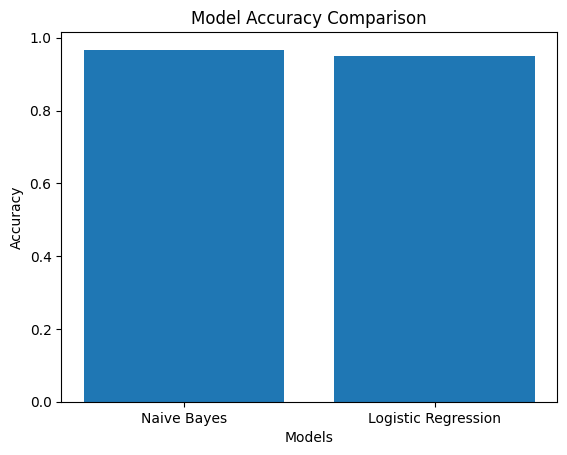

In [83]:
# Compare accuracy
score1 = nb.score(X_test_tfidf, y_test)
score2 = lr.score(X_test_tfidf, y_test)
models = ['Naive Bayes', 'Logistic Regression']
scores = [score1, score2]
plt.bar(models, scores)
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()